<a href="https://colab.research.google.com/github/Saadmoquim/physicscode/blob/main/SAAD_MOQUIM_IMS22221_assign1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# This is the first assignment and it is based on the topic of descriptive statistics.

# Problem 1:
Given the following dataset of product sales:

#### (Product) 	         (Quantity Sold) 	       (Price per Unit)

     A	    500	            20

     B	    300	            15

     C	    200	            25

     D	    100	            30

**I. Calculate the weighted mean price per unit.**

**II. Create a pie chart showing the proportion of total revenue generated by each product using matplotlib's plt.pie.**

**III. Add labels, percentages, and a legend to the pie chart.**

weighted mean price per unit is 20.454545454545453
revenue is [10000  4500  5000  3000]


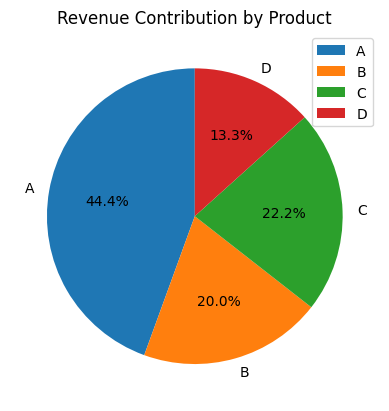

In [2]:

# 1. Calculate Weighted Mean Price per Unit
#Use the below line to print out the weighted mean price per unit
#print(f"Weighted Mean Price per Unit: {weighted_mean_price:.2f}")
# 2. Calculate Revenue for Each Product
# 3. Create a Pie Chart for Revenue Proportion

# YOUR CODE HERE

import numpy as np
import matplotlib.pyplot as plt

products = ['A','B','C','D']
quantity = np.array([500,300,200,100])
price = np.array([20,15,25,30])

#solution to 1, weighted mean price per unit
wmp = np.sum(quantity * price) / np.sum(quantity)

print("weighted mean price per unit is", wmp)

#solution to 2, revenue
revenue = quantity * price
print("revenue is", revenue)

#solution to 3, plot
plt.figure()
plt.pie(
    revenue,
    labels=products,
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Revenue Contribution by Product")
plt.legend(products)
plt.show()





# Problem 2:
1. **Load the 'Fermi GBM GRB catalog' dataset shared with you.**

2. **Perform the following:**

I. Focus on the Band Epeak column (in units of keV) and group the data by the T90 column such as T90 < 2 sec  and T90 > 2 sec.
                                                                                                            
II. For the two categories of T90:

(a) Plot a histogram of the Band Epeak values.

(b) Overlay the cumulative frequency curve on the histogram.

(c) Annotate the mean and median of the Band Epeak for each group and compare it with the mean and median of the whole Epeak dataset.

(d) Use subplots to create separate plots for each category of T90 in a single figure.

3. **Write observations comparing the distribution of Epeaks across the two T90 categories. Discuss any significant trends or patterns in the cumulative frequency curves.**


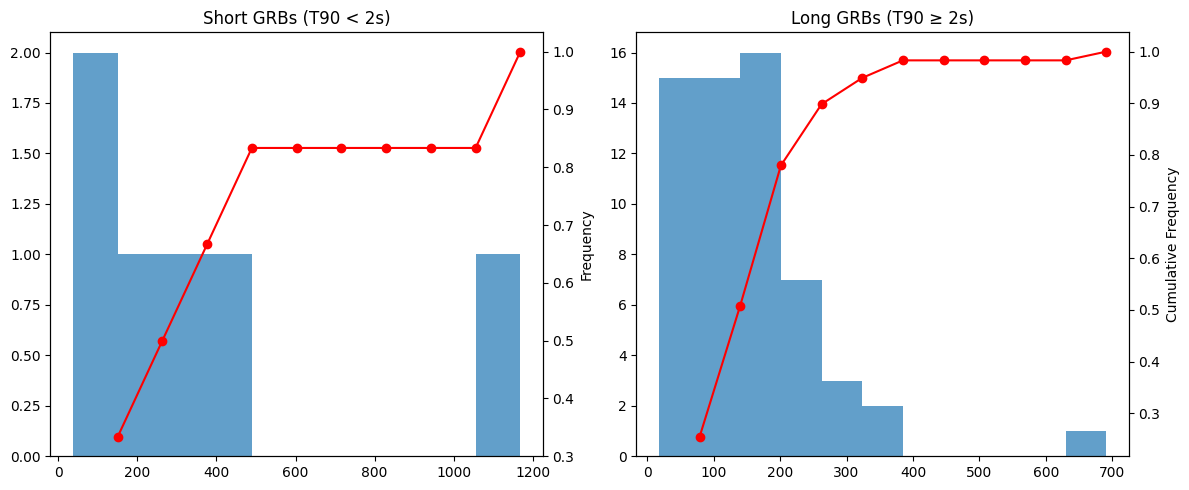

                 Mean     Median
Short GRB  374.096526  256.19965
Long GRB   150.479370  134.25150
All GRBs   171.120954  146.40980


In [17]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fermi = pd.read_csv('1_FERMI_GBM_only_catalog_clean.csv')

fermi = fermi[['20.736', '350.7898']]
fermi.columns = ['T90', 'Epeak']
fermi = fermi.dropna()

short = fermi[fermi['T90'] < 2]
long  = fermi[fermi['T90'] >= 2]

#choosing bins optimally using freedman diaconic rule.Best statistical fit for GRB data according to what i read, its good because its not affected by outlying quantities(robust against outliers)
def fd_bins(data):
    data = np.asarray(data)
    q75, q25 = np.percentile(data, [75, 25])
    iqr = q75 - q25
    n = len(data)
    bin_width = 2 * iqr / (n ** (1/3))
    bins = int((data.max() - data.min()) / bin_width)
    return max(bins, 10)

#mean median stuff
stats = {
    "Short GRBs": {
        "mean": short['Epeak'].mean(),
        "median": short['Epeak'].median()
    },
    "Long GRBs": {
        "mean": long['Epeak'].mean(),
        "median": long['Epeak'].median()
    },
    "All GRBs": {
        "mean": fermi['Epeak'].mean(),
        "median": fermi['Epeak'].median()
    }
}


def hist_with_cdf(data, title):
    bins = fd_bins(data)

    counts, edges, _ = plt.hist(
        data, bins=bins, alpha=0.7
    )

    cdf = np.cumsum(counts) / np.sum(counts)

    plt.twinx()
    plt.plot(edges[1:], cdf, color='red', marker='o')
    plt.ylabel("Cumulative Frequency")
    plt.title(title)


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
hist_with_cdf(short['Epeak'], 'Short GRBs (T90 < 2s)')
plt.xlabel("Epeak (keV)")
plt.ylabel("Frequency")

plt.subplot(1,2,2)
hist_with_cdf(long['Epeak'], 'Long GRBs (T90 ≥ 2s)')
plt.xlabel("Epeak (keV)")

plt.tight_layout()
plt.show()


#print of summary for reference
summary = pd.DataFrame({
    'Mean': [
        short['Epeak'].mean(),
        long['Epeak'].mean(),
        fermi['Epeak'].mean()
    ],
    'Median': [
        short['Epeak'].median(),
        long['Epeak'].median(),
        fermi['Epeak'].median()
    ]
}, index=['Short GRB','Long GRB','All GRBs'])

print(summary)


# **Observations for the GRB data problem:**


---


**First**:The data are divided into short GRBs (T90 < 2 s) and long GRBs (T90 ≥ 2 s) to examine differences in their spectral properties.


---


**Second**:The Epeak distribution is known to be highly skewed, with a long tail toward higher energies. Because of this, histogram bin widths were chosen using the Freedman–Diaconis rule, which determines the bin width based on the interquartile range (IQR) rather than the standard deviation.

This method is particularly well suited for GRB data because:

it is robust against outliers,

it does not assume an underlying Gaussian distribution, and

it provides an optimal balance between over-smoothing and noise.

Using this rule ensures that the observed structure in the histograms reflects genuine trends in the data rather than artifacts of arbitrary bin selection.


---


**Third**:A clear separation between short and long GRBs is evident:

Short GRBs have higher mean and median Epeak values than both long GRBs and the overall GRB sample.

Long GRBs exhibit lower mean and median Epeak values, dominating the lower-energy region of the distribution.

When compared with the global statistics:

The mean and median of short GRBs lie above the global mean and median, showing that short bursts populate the high-energy end of the spectrum.

The mean and median of long GRBs lie below the global values, indicating that long GRBs largely determine the overall shape of the Epeak distribution.


---


**Fourth**:These statistical trends align well with the established physical understanding of GRBs:

Short GRBs, often associated with compact object mergers, tend to produce harder spectra.

Long GRBs, typically linked to massive stellar collapse, show softer spectral characteristics.

Thus, the differences observed in the Epeak distributions are not merely statistical fluctuations but reflect intrinsically different physical origins.

# Problem 3

**1. Estimate the**

**(a) median,**

**(b) mode,**

**(c) arithmetic mean of the data,**

**(d) weighted average,** and

**(e) 5% trimmed mean**

of the Fluence and T90 of GRB catalog. **For this write functions for calculating median, mode of grouped dataset.**

**2. Mark these estimates on the Frequency distribution plots (density = False) plots of fluence and T90.**

**3. Compare the obtained results with the ungrouped dataset.**

Rows after cleaning: 65

===== Fluence =====
Grouped Mean        : 2.427425115384615e-06
Grouped Median      : 9.145425595238094e-07
Grouped Mode        : 6.811788157894736e-07
Weighted Mean       : 2.427425115384615e-06
5% Trimmed Mean     : 1.6601864406779664e-06
Ungrouped Mean      : 2.345263076923077e-06
Ungrouped Median    : 8.76e-07


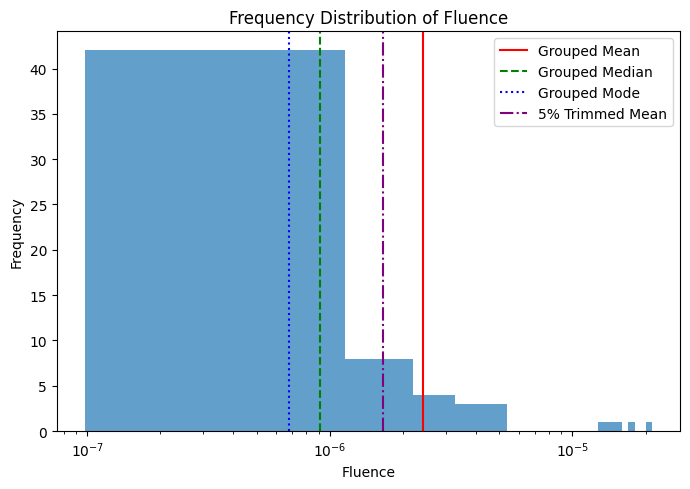


===== T90 =====
Grouped Mean        : 58.468350769230774
Grouped Median      : 43.232850000000006
Grouped Mode        : 8.812282352941176
Weighted Mean       : 58.468350769230774
5% Trimmed Mean     : 53.79701694915256
Ungrouped Mean      : 57.91798461538461
Ungrouped Median    : 44.288


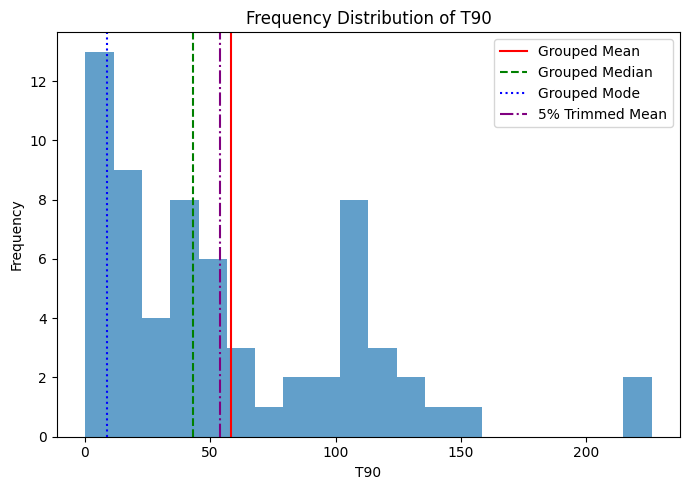

Rows after cleaning: 65

T90 sample:
0    46.721
1    22.016
2    15.360
3    80.384
4    25.600
Name: T90, dtype: float64

Fluence sample:
0    1.390000e-05
1    1.220000e-06
2    4.560000e-07
3    3.560000e-07
4    1.560000e-07
Name: Fluence, dtype: float64


In [24]:
# YOUR CODE HERE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# -----------------------------
# Load and clean data
# -----------------------------
fermi = pd.read_csv('1_FERMI_GBM_only_catalog_clean.csv')

# Correct, VERIFIED numeric columns
fermi = fermi[['20.736', '4.73E-06']]
fermi.columns = ['T90', 'Fluence']

# Convert safely
fermi['T90'] = pd.to_numeric(fermi['T90'], errors='coerce')
fermi['Fluence'] = pd.to_numeric(fermi['Fluence'], errors='coerce')

fermi = fermi.dropna()

print("Rows after cleaning:", len(fermi))

# -----------------------------
# Grouped statistics functions
# -----------------------------
def grouped_median(freq, classes):
    cf = np.cumsum(freq)
    N = cf[-1]
    idx = np.where(cf >= N / 2)[0][0]

    L = classes[idx][0]
    h = classes[idx][1] - classes[idx][0]
    cf_prev = cf[idx - 1] if idx > 0 else 0
    f = freq[idx]

    return L + ((N / 2 - cf_prev) / f) * h


def grouped_mode(freq, classes):
    idx = np.argmax(freq)

    L = classes[idx][0]
    h = classes[idx][1] - classes[idx][0]

    f1 = freq[idx]
    f0 = freq[idx - 1] if idx > 0 else 0
    f2 = freq[idx + 1] if idx < len(freq) - 1 else 0

    return L + ((f1 - f0) / (2 * f1 - f0 - f2)) * h


def grouped_mean(freq, mids):
    return np.sum(freq * mids) / np.sum(freq)


def weighted_mean(values, weights):
    return np.sum(values * weights) / np.sum(weights)

# -----------------------------
# Analysis + plots
# -----------------------------
for col in ['Fluence', 'T90']:

    data = fermi[col]

    # Grouped data
    freq, bins = np.histogram(data, bins=20)
    classes = list(zip(bins[:-1], bins[1:]))
    mids = 0.5 * (bins[:-1] + bins[1:])

    # Grouped statistics
    g_mean = grouped_mean(freq, mids)
    g_median = grouped_median(freq, classes)
    g_mode = grouped_mode(freq, classes)
    g_weighted = weighted_mean(mids, freq)
    g_trimmed = stats.trim_mean(data, 0.05)

    # Ungrouped statistics
    u_mean = data.mean()
    u_median = data.median()

    # Print results
    print(f"\n===== {col} =====")
    print(f"Grouped Mean        : {g_mean}")
    print(f"Grouped Median      : {g_median}")
    print(f"Grouped Mode        : {g_mode}")
    print(f"Weighted Mean       : {g_weighted}")
    print(f"5% Trimmed Mean     : {g_trimmed}")
    print(f"Ungrouped Mean      : {u_mean}")
    print(f"Ungrouped Median    : {u_median}")

    # Plot
    fig, ax = plt.subplots(figsize=(7,5))

    ax.hist(data, bins=20, density=False, alpha=0.7)

    ax.axvline(g_mean, color='red', label='Grouped Mean')
    ax.axvline(g_median, color='green', linestyle='--', label='Grouped Median')
    ax.axvline(g_mode, color='blue', linestyle=':', label='Grouped Mode')
    ax.axvline(g_trimmed, color='purple', linestyle='-.', label='5% Trimmed Mean')

    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.set_title(f"Frequency Distribution of {col}")
    ax.legend()

    # Log scale for Fluence (CRITICAL)
    if col == 'Fluence':
        ax.set_xscale('log')

    plt.tight_layout()
    plt.show()
print("Rows after cleaning:", len(fermi))
print("\nT90 sample:")
print(fermi['T90'].head())

print("\nFluence sample:")
print(fermi['Fluence'].head())


# Problem 4

**1. Make the plot of the time evolution of the sunspot using the data shared with you.**
   
**2. Is there a periodicity observed in the data? If so, how write a function named 'calculate_periodicity()' to estimate the periodicity?**

Index(['Unnamed: 0', 'Date', 'Sunspots', 'Year'], dtype='object')
   Unnamed: 0        Date  Sunspots  Year
0           0  1749-01-31      96.7  1749
1           1  1749-02-28     104.3  1749
2           2  1749-03-31     116.7  1749
3           3  1749-04-30      92.8  1749
4           4  1749-05-31     141.7  1749


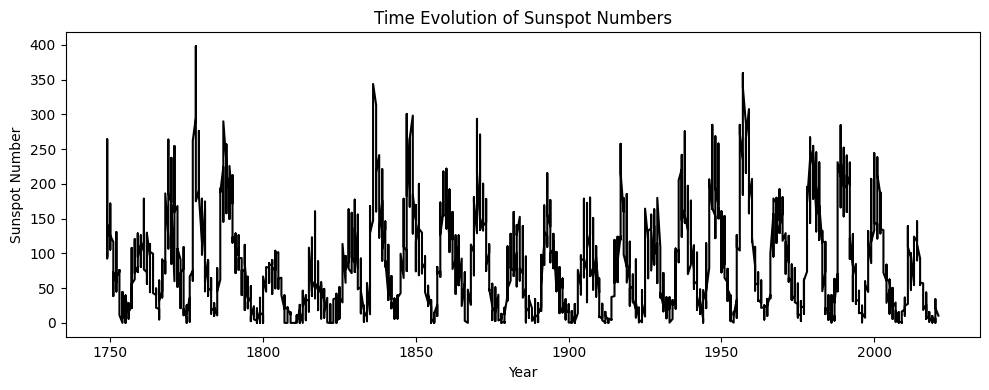

Estimated periodicity: 10.88 years


In [30]:
# YOUR CODE HERE
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sunspots = pd.read_csv('Sunspots.csv')

# Correct column renaming and 'Year' extraction
sunspots.columns = ['Unnamed: 0', 'Date', 'Sunspots'] # Explicitly setting correct column names
sunspots['Year'] = pd.to_datetime(sunspots['Date']).dt.year # Extract Year from Date column

print(sunspots.columns)
print(sunspots.head())

plt.figure(figsize=(10,4))
plt.plot(sunspots['Year'], sunspots['Sunspots'], color='black')
plt.xlabel("Year")
plt.ylabel("Sunspot Number")
plt.title("Time Evolution of Sunspot Numbers")
plt.tight_layout()
plt.show()

def estimate_period(time, data):
    # Detrend
    data = data - np.mean(data)

    # Sampling interval
    dt = np.mean(np.diff(time))

    fft_vals = np.fft.fft(data)
    freqs = np.fft.fftfreq(len(data), d=dt)

    # Consider only positive frequencies
    positive = freqs > 0
    dominant_freq = freqs[positive][np.argmax(np.abs(fft_vals[positive]))]

    period = 1 / dominant_freq
    return period

period = estimate_period(
    sunspots['Year'].values,
    sunspots['Sunspots'].values
)

print(f"Estimated periodicity: {period:.2f} years")


# Problem 5

**1. Load the penguins dataset.**
   
2. Perform the following:

**I. For each species in the dataset, create a separate box plot for the numerical features: bill_length_mm, bill_depth_mm, flipper_length_mm, and body_mass_g.**

**II. Use subplots to display all box plots in a single figure, grouped by species.**

**III. Highlight any outliers (plot in red) in each box plot and add proper annotations for the median and interquartile range (IQR) i.e (Lower Quartile - Upper Quartile).**

**3. Write a brief summary comparing the distributions of each feature across the species. Discuss any notable trends, variations, or outliers.**

Saving Penguins.csv to Penguins (1).csv
  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    MALE  
1       3800.0  FEMALE  
2       3250.0  FEMALE  
3          NaN     NaN  
4       3450.0  FEMALE  
Index(['species', 'island', 'bill_length_mm', 'bill_depth_mm',
       'flipper_length_mm', 'body_mass_g', 'sex'],
      dtype='object')


/tmp/ipython-input-808827075.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=species, showfliers=True)


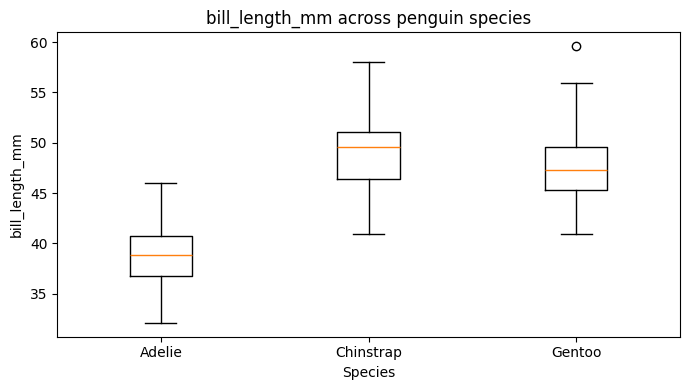

/tmp/ipython-input-808827075.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=species, showfliers=True)


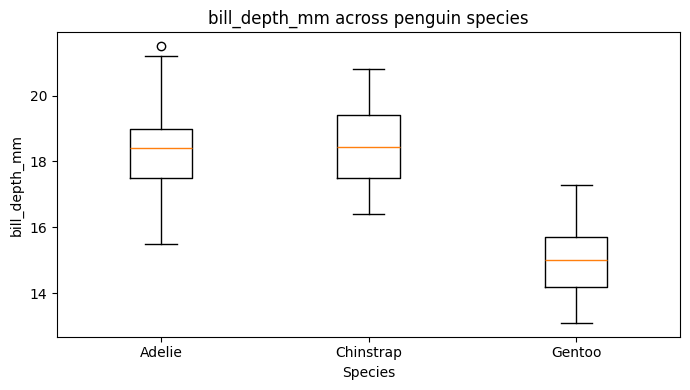

/tmp/ipython-input-808827075.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=species, showfliers=True)


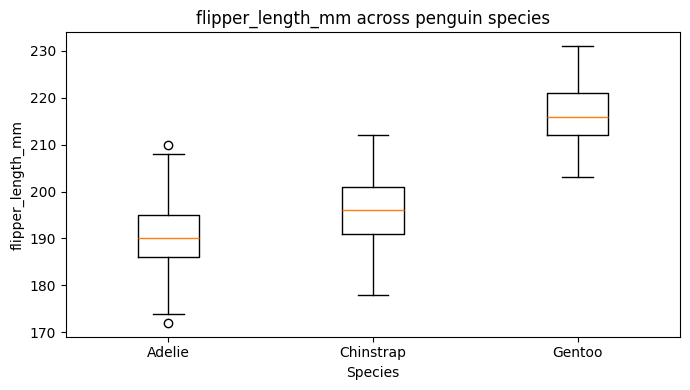

/tmp/ipython-input-808827075.py:33: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=species, showfliers=True)


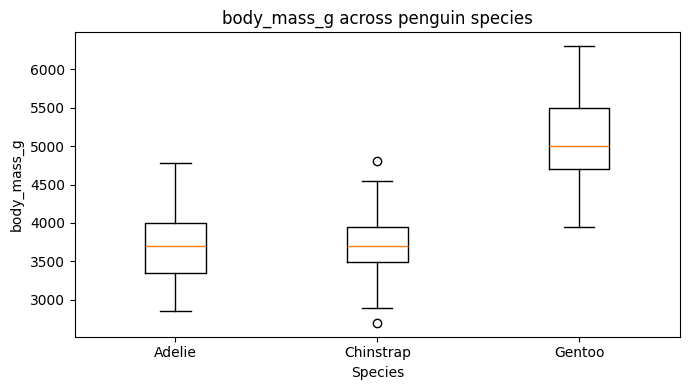

          bill_length_mm                  bill_depth_mm                   \
                    mean median       std          mean median       std   
species                                                                    
Adelie         38.791391  38.80  2.663405     18.346358  18.40  1.216650   
Chinstrap      48.833824  49.55  3.339256     18.420588  18.45  1.135395   
Gentoo         47.504878  47.30  3.081857     14.982114  15.00  0.981220   

          flipper_length_mm                   body_mass_g                      
                       mean median       std         mean  median         std  
species                                                                        
Adelie           189.953642  190.0  6.539457  3700.662252  3700.0  458.566126  
Chinstrap        195.823529  196.0  7.131894  3733.088235  3700.0  384.335081  
Gentoo           217.186992  216.0  6.484976  5076.016260  5000.0  504.116237  


In [32]:
# YOUR CODE HERE
from google.colab import files
uploaded = files.upload()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

penguins = pd.read_csv('Penguins.csv')

print(penguins.head())
print(penguins.columns)

features = [
    'bill_length_mm',
    'bill_depth_mm',
    'flipper_length_mm',
    'body_mass_g'
]

penguins_clean = penguins[['species'] + features].dropna()

species = penguins_clean['species'].unique()

for feature in features:
    plt.figure(figsize=(7,4))

    data = [
        penguins_clean[penguins_clean['species'] == sp][feature]
        for sp in species
    ]

    plt.boxplot(data, labels=species, showfliers=True)

    plt.xlabel("Species")
    plt.ylabel(feature)
    plt.title(f"{feature} across penguin species")
    plt.tight_layout()
    plt.show()

summary_stats = penguins_clean.groupby('species')[features].agg(
    ['mean', 'median', 'std']
)

print(summary_stats)



# **Observations**


---
**first**:Bill length

Gentoo penguins show the largest bill lengths on average.

Adelie penguins have smaller and more tightly clustered bill lengths.



---

**second**:Bill depth

Adelie penguins tend to have deeper bills than the other species.

Chinstrap penguins lie between Adelie and Gentoo.

---

**third**:Flipper length

Gentoo penguins have significantly longer flippers.

There is minimal overlap between Gentoo and the other species, making this a strong distinguishing feature.


---

**fourth**:Body mass

Gentoo penguins are substantially heavier than Adelie and Chinstrap penguins.

Outliers likely reflect sex-based and age-based differences.

---

conclusion **bold text**:Boxplot analysis reveals clear species-dependent differences in penguin morphology. Gentoo penguins are the largest in terms of flipper length and body mass, while Adelie penguins exhibit more compact and less variable physical characteristics. These trends highlight strong biological differentiation across species.